In [2]:
import numpy as np
from datetime import datetime as dt
import csv
import random
import copy

def nonlinspace(start, stop, num):
    linear = np.linspace(0, 1, num)
    my_curvature = 1
    curve = 1 - np.exp(-my_curvature*linear)
    # Normalise between 0 and 1
    curve = curve/np.max(curve)
    #curve = curve*(stop - start-1) + start # don't minus 1 cause everything is between 0-1 for our use case.
    curve = curve * (stop - start) + start
    # Convert the curve from np to floats
    curve = [float(i) for i in curve]
    return curve

def generate_prips(agent_groups, curve_groups):
    """Generates one preference for egalitarianism and returns as a dict of agents/prips.
    Note that there is no alignment here with PVSs, so this should be considered manually."""
    prips = {}
    for curve_group, agents in agent_groups.items():
        curve_values = curve_groups[curve_group][0]
        for agent in agents:
            random_index = random.randint(0, len(curve_values)-1)
            prips[agent] = curve_values[random_index]
    print(prips)
    return prips

def generate_ps(agent_groups, curve_groups, n_values):
    """Generates value preferences for n_values different values for a given number of agents"""
    value_preferences = {}
    # Get the first round of strengths
    for curve_group, agents in agent_groups.items():
        opposing_curve_group_index = len(curve_groups) - (1+list(curve_groups.keys()).index(curve_group))
        opposing_curve_group = list(curve_groups.keys())[opposing_curve_group_index]
        curve_values = curve_groups[curve_group][0]
        opposing_curve_values = curve_groups[opposing_curve_group][0]
        # For every agent
        for agent in agents:
            agent_strengths = []
            # Find the strength for half of values.
            agent_strengths = random.choices(curve_values, k=int(n_values/2))
            # Find the opposing strengths for the other half
            agent_strengths = agent_strengths + (random.choices(opposing_curve_values, k=int(n_values/2)))
            agent_strengths = np.array(agent_strengths)
            # Find agent preferences from the strength of preference for each value
            # For every value in the values list, compare it to every other value
            diff = agent_strengths[:, np.newaxis] - agent_strengths
            # Diff norm normalises the value preferences between 0 and 1
            diff_norm = (diff - np.min(diff)) / (np.max(diff) - np.min(diff))
            value_preferences[agent] = copy.copy(diff_norm)
    return value_preferences

def generate_vas(agent_groups, curve_groups, value_preferences, n_values):
    """Generates action judgements for certain actions and preferences, returns as a dict of agents/vas"""
    action_judgements = {}
    # Get the strengths
    for curve_group, agents in agent_groups.items():
        opposing_curve_group_index = len(curve_groups) - (1 + list(curve_groups.keys()).index(curve_group))
        opposing_curve_group = list(curve_groups.keys())[opposing_curve_group_index]
        curve_values = curve_groups[curve_group][0]
        opposing_curve_values = curve_groups[opposing_curve_group][0]
        # For every agent
        for agent in agents:
            agent_strengths = []
            # Find the strength for half of values.
            agent_strengths = random.choices(curve_values, k=int(n_values / 2))
            # Find the opposing strengths for the other half
            agent_strengths = agent_strengths + (random.choices(opposing_curve_values, k=int(n_values / 2)))
            agent_strengths = np.array(agent_strengths)

            # Convert to action judgments considering value preferences
            x = value_preferences[agent].shape[0]
            # Convert the preferences to range [-1,1], where shifted_prefs[x,y] >0 means x preferred to y
            shifted_prefs = 2.0 * (value_preferences[agent] - 0.5)
            # Convert the shifted prefs to a symmetric matrix, and
            #   then show preference relative to every other value. as a 1D array
            np.fill_diagonal(shifted_prefs, 0.0)
            # The clipping below should protect against divide by 0 cases, if any arise.
            strengths_of_prefs = shifted_prefs.sum(axis=1) / float(x - 1)
            strengths_of_prefs = np.clip(strengths_of_prefs, -1.0, 1.0)
            # Get the centred actions computed above and clip for sanity
            centred_actions = agent_strengths
            centred_actions = np.clip(centred_actions, -1.0, 1.0)
            ## Finally, convert the centred actions to judgements by multiplying by the strength
            judgements = np.outer(strengths_of_prefs, centred_actions)
            judgements = np.clip(judgements, -1.0, 1.0)
            action_judgements[agent] = copy.copy(judgements)
    return action_judgements

def save_to_file(value_preferences, action_judgements, principle_prefs, agents_ids, n_values, n_acts):
    now = dt.now().isoformat()
    principles_fn = now+"_PriP.csv"
    # Principles:
    with open(principles_fn, 'w', newline='') as csvfile:
        writer = csv.writer(csvfile)
        # Header
        header = ["country", "Egalitarian"]
        writer.writerow(header)
        # Rows
        for country in agents_ids:
            PriP = principle_prefs[country]
            row = [country, PriP]
            writer.writerow(row)

    # Values + Preferences + Action Judgements
    values_fn = now + "_PVS.csv"
    with open(values_fn, 'w', newline='') as csvfile:
        writer = csv.writer(csvfile)
        # Header
        header = ["country"]
        # P__vi__vj columns
        for vi in range(n_values):
            for vj in range(n_values):
                header.append(f"P__{vi}__{vj}")
        # VA__v__a columns
        for v in range(n_values):
            for a in range(n_acts):
                header.append(f"VA__{v}__{a}")
        writer.writerow(header)
        # Rows
        for agent in agents_ids:
            P = np.array(value_preferences[agent], dtype=float)
            VA = np.array(action_judgements[agent], dtype=float)

            row = [agent]
            for i in range(n_values):
                for j in range(n_values):
                    row.append(float(P[i, j]))

            for i in range(n_values):
                for k in range(n_acts):
                    row.append(float(VA[i, k]))

            writer.writerow(row)
    return

Seed is:  26516224803955210800272177681296642830
[-0.24333094 -0.00073582  0.12707039 ...  0.34873081  0.35463902
 -0.115435  ]


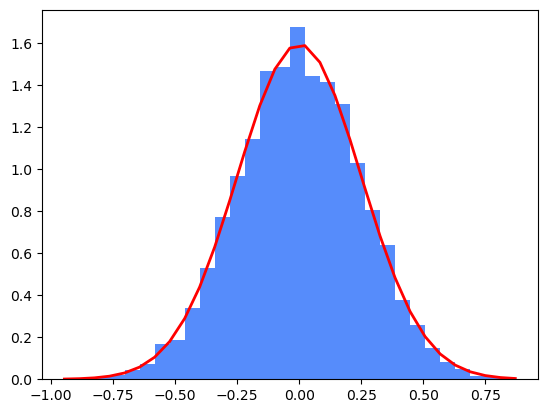

In [11]:
## Pushing mu further one way or another for prips and pvs' independently

## How are we going to deal with the fact that we want someone who likes values v1 and v2, to also like a1 and a2, and that will be a correlation? So we need to define that? Yes...

## To correlate preferring certain values with certain actions, we intend to sample from a normal distribution to find our p's, and then we simply normalise that to an action judgement, adding some random noise. This means that we can change the level of correlation depending on the level of noise!

# First, make a normal distribution

# Make a seed following numpy guidance
import secrets
seed = secrets.randbits(128)
print("Seed is: ", seed)
rng = np.random.default_rng(seed=seed)

mu, sigma = 0, 0.25
s = rng.normal(mu,sigma, size=10000)

print(s)

import matplotlib.pyplot as plt
count, bins, _ = plt.hist(s, 30, density=True)
plt.plot(bins, 1/(sigma * np.sqrt(2 * np.pi)) *
               np.exp( - (bins - mu)**2 / (2 * sigma**2) ),
         linewidth=2, color='r')
plt.show()


In [3]:
## Second,